# Q5 Regression Pipeline (Batch Normalize 후 Regression)

## 목적
- Batch effect 제거 (batch normalization)
- Stable feature로 regression 수행
- RMSE 평가

이 notebook은 **EDA 이후 Modeling 단계**입니다.
Batch normalize는 Feature Engineering + Data Preprocessing 단계에 해당합니다.


## 1. 필요한 라이브러리 import

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

import matplotlib.pyplot as plt
import seaborn as sns


## 2. Feature 선택

EDA에서 안정적이었던 feature만 사용


In [20]:
features = [

'charge_time_mean',
'QDischarge_delta_100_10',
'IR_delta',
'QDischarge_delta',
'IR_mean',
'QDischarge_mean'

]

target = 'cycle_life'


## 3. Batch Normalize (핵심 단계)

Batch별 평균/표준편차로 normalize
논문에서도 batch effect 제거가 중요


In [21]:
df1 = pd.read_csv("../results/batch1_features.csv")

df2 = pd.read_csv("../results/batch2_features.csv")

df3 = pd.read_csv("../results/batch3_features.csv")

In [22]:
df1['batch']='B1'
df2['batch']='B2'
df3['batch']='B3'

In [23]:
df_all = pd.concat([df1,df2,df3])

In [24]:
df_all = df_all.dropna(subset=['cycle_life'])

df_all = df_all[df_all['Tmax_mean'] < 80]

In [25]:
def batch_normalize(df):

    df_norm = df.copy()

    cols = features   # feature만!

    df_norm[cols] = df.groupby('batch')[cols].transform(

        lambda x:(x-x.mean())/(x.std()+1e-8)

    )

    return df_norm

## 4. Train/Test split

In [26]:
df_norm = batch_normalize(df_all)

In [27]:
X = df_norm[features]

y = df_norm[target]

X_train,X_test,y_train,y_test = train_test_split(

    X,y,test_size=0.2,random_state=42

)


## 5. Linear Regression

In [28]:
df_all[df_all['cycle_life'].isna()]

,cycle_life,IR_mean,QDischarge_mean,Tmax_mean,Tavg_mean,charge_time_mean,IR_delta,QDischarge_delta,IR_delta_100_10,QDischarge_delta_100_10,IR_var,QDischarge_var,batch


In [29]:
df_norm.isna().sum()

cycle_life                 0
IR_mean                    0
QDischarge_mean            0
Tmax_mean                  0
Tavg_mean                  0
charge_time_mean           0
IR_delta                   0
QDischarge_delta           0
IR_delta_100_10            0
QDischarge_delta_100_10    0
IR_var                     0
QDischarge_var             0
batch                      0
dtype: int64

In [30]:
df_norm.shape

(129, 13)

In [31]:
lr = LinearRegression()

lr.fit(X_train,y_train)

pred_lr = lr.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test,pred_lr))

print("Linear RMSE:",rmse_lr)


Linear RMSE: 231.61722872047125


## 6. Random Forest

In [32]:
rf = RandomForestRegressor(

    n_estimators=300,
    max_depth=6,
    random_state=42

)

rf.fit(X_train,y_train)

pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test,pred_rf))

print("RF RMSE:",rmse_rf)


RF RMSE: 183.63449232100825


## 7. Feature Importance

In [33]:
importance = pd.Series(

rf.feature_importances_,
index=features

).sort_values(ascending=False)

importance


charge_time_mean           0.692404
QDischarge_delta           0.094241
IR_mean                    0.067442
IR_delta                   0.062907
QDischarge_mean            0.045230
QDischarge_delta_100_10    0.037776
dtype: float64

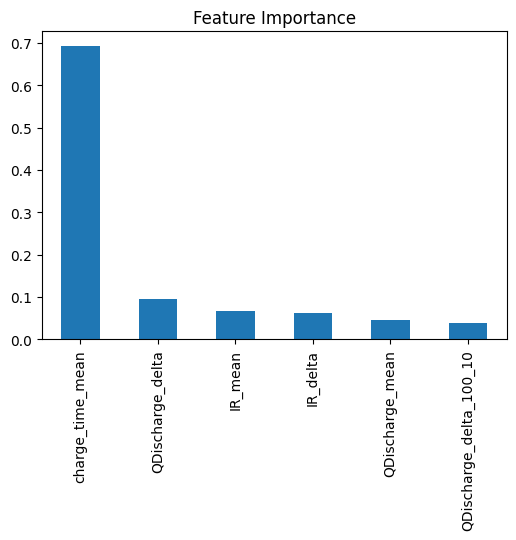

In [34]:
plt.figure(figsize=(6,4))

importance.plot(kind='bar')

plt.title("Feature Importance")

plt.show()


## 8. 실제값 vs 예측값

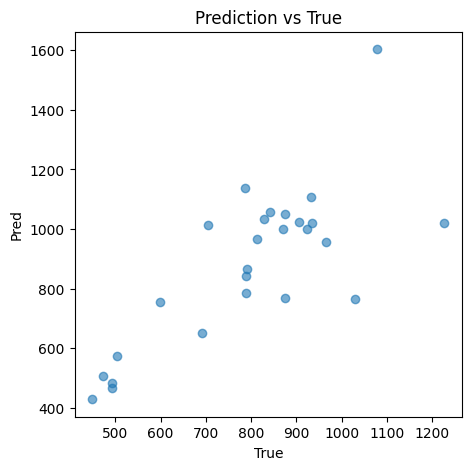

In [35]:
plt.figure(figsize=(5,5))

plt.scatter(y_test,pred_rf,alpha=0.6)

plt.xlabel("True")

plt.ylabel("Pred")

plt.title("Prediction vs True")

plt.show()
